In [ ]:
import pandas as pd
import numpy as np
import os
from keras.utils import to_categorical

extracted_landmarks_dir = '../datasets/bukva_processed/processed_landmarks_2d'
csv_path = '../datasets/bukva_processed/annotations.csv'
save_dir = os.path.join('../models', 'proposed/')
os.makedirs(save_dir, exist_ok=True)

In [ ]:
df = pd.read_csv(csv_path, sep="\t")
df = df.drop(columns=['user_id', 'begin', 'end', 'length'])

df.head()

,attachment_id,text,height,width,train
0,df5b08f0-41d1-4572-889c-8b893e71069b,А,1920,1080,False
1,3d2b6a08-131d-40a9-9533-cf45cefb07fd,А,1920,1080,True
2,1915f996-71ed-44ae-9a34-ee1959919238,А,1920,1080,True
3,bfb2d7ae-0f6c-4e20-b087-0965641d34ff,А,1080,1920,False
4,24936cc5-e5bb-43a3-96b8-2a9b4a6d157f,А,1080,1920,False


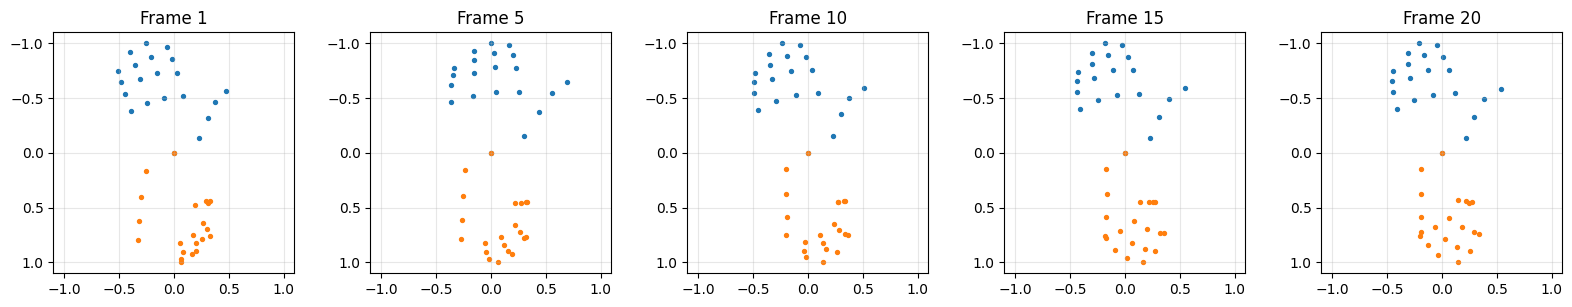

Shape of numpy file: (24, 86)


In [ ]:
import matplotlib.pyplot as plt

file_path = os.path.join(extracted_landmarks_dir, '0a1b79d6-3b30-4fc8-8755-365c17884892.npy')
data = np.load(file_path)

selected_frames = [0, 4, 9, 14, 19]

# Plot the file for the visualization of landmarks
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for i, f_idx in enumerate(selected_frames):
    # Left hand
    if data[f_idx, 0] == 1:
        pts = data[f_idx, 1:43].reshape(21, 2)
        axes[i].scatter(pts[:, 0], pts[:, 1], s=8)

    # Right hand
    if data[f_idx, 43] == 1:
        pts = data[f_idx, 44:86].reshape(21, 2)
        axes[i].scatter(pts[:, 0], pts[:, 1], s=8)

    axes[i].set_title(f"Frame {f_idx + 1}")
    axes[i].set_xlim(-1.1, 1.1)
    axes[i].set_ylim(1.1, -1.1)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_aspect("equal")

plt.tight_layout()
plt.show()

print(f"Shape of numpy file: {data.shape}")

In [ ]:
# Map each label to number
label_map = {
    "no_event": 0, "Ё": 1, "А": 2, "Б": 3, "В": 4, "Г": 5, "Д": 6, "Е": 7,
    "Ж": 8, "З": 9, "И": 10, "Й": 11, "К": 12, "Л": 13, "М": 14, "Н": 15,
    "О": 16, "П": 17, "Р": 18, "С": 19, "Т": 20, "У": 21, "Ф": 22, "Х": 23,
    "Ц": 24, "Ч": 25, "Ш": 26, "Щ": 27, "Ъ": 28, "Ы": 29, "Ь": 30, "Э": 31,
    "Ю": 32, "Я": 33
}

sequences, labels = [], []

# Map the text labels to numeric IDs directly in the DataFrame
df['label_id'] = df['text'].map(label_map)

# Check for any failed mappings (typos in CSV)
if df['label_id'].isnull().any():
    print("Warning: Some rows failed to map! Check your CSV 'text' column.")
    print(df[df['label_id'].isnull()])

df.head()

,attachment_id,text,height,width,train,label_id
0,df5b08f0-41d1-4572-889c-8b893e71069b,А,1920,1080,False,2
1,3d2b6a08-131d-40a9-9533-cf45cefb07fd,А,1920,1080,True,2
2,1915f996-71ed-44ae-9a34-ee1959919238,А,1920,1080,True,2
3,bfb2d7ae-0f6c-4e20-b087-0965641d34ff,А,1080,1920,False,2
4,24936cc5-e5bb-43a3-96b8-2a9b4a6d157f,А,1080,1920,False,2


In [ ]:
# Prepare train and test data according to csv provided by dataset
train_sequences, train_labels = [], []
test_sequences, test_labels = [], []

for _, row in df.iterrows():
    file_path = os.path.join(extracted_landmarks_dir, f"{row['attachment_id']}.npy")
    if os.path.exists(file_path):
        data = np.load(file_path)
        # Directly the mapped label ID
        label = row['label_id']

        if row['train'] == True:
            train_sequences.append(data)
            train_labels.append(label)
        else:
            test_sequences.append(data)
            test_labels.append(label)

# Convert to numpy arrays and use one-hot encoding instead of embedding (there are 34 classes)
X_train = np.array(train_sequences)
y_train = to_categorical(train_labels, num_classes=34).astype(int)

X_test = np.array(test_sequences)
y_test = to_categorical(test_labels, num_classes=34).astype(int)

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization

model = Sequential([
    LSTM(64, input_shape=(24, 86), return_sequences=False), # Input is 24,86
    BatchNormalization(), # Keeps values stable, which helps with small inputs
    Dropout(0.4), # To prevent the model from memorizing your specific training videos
    Dense(64, activation='relu'), # A single dense layer for decision making
    Dense(34, activation='softmax') # Output layer (34 classes)
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping to avoid overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    os.path.join(save_dir, 'best_model_xy.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.0614 - loss: 3.6300
Epoch 1: val_loss improved from None to 3.24780, saving model to /content/drive/MyDrive/models/best_model_xy.keras

Epoch 1: finished saving model to /content/drive/MyDrive/models/best_model_xy.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - categorical_accuracy: 0.0993 - loss: 3.3791 - val_categorical_accuracy: 0.1985 - val_loss: 3.2478
Epoch 2/50
 95/100 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.2269 - loss: 2.6907
Epoch 2: val_loss improved from 3.24780 to 2.52021, saving model to /content/drive/MyDrive/models/best_model_xy.keras

Epoch 2: finished saving model to /content/drive/MyDrive/models/best_model_xy.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - categorical_accuracy: 0.2656 - loss: 2.5174 - val_categorical_accuracy: 0.3118 - val_loss: 2.5202
Epoch 3/50
 98/100 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.4030 - loss: 1.9671
Epoch 3: val_loss i

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions on the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Print Classification Report
print(classification_report(y_true, y_pred, target_names=list(label_map.keys())))

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
              precision    recall  f1-score   support

    no_event       0.74      0.85      0.79        20
           Ё       0.56      0.50      0.53        20
           А       0.95      0.95      0.95        20
           Б       0.90      0.90      0.90        20
           В       0.77      0.85      0.81        20
           Г       0.87      1.00      0.93        20
           Д       0.71      0.60      0.65        20
           Е       0.83      0.50      0.62        20
           Ж       0.50      0.75      0.60        20
           З       0.88      0.75      0.81        20
           И       0.85      0.55      0.67        20
           Й       0.82      0.90      0.86        20
           К       1.00      0.70      0.82        20
           Л       0.70      0.35      0.47        20
           М       0.62      0.75      0.68        20
           Н       0.78      0.90      0.84        20
           О       0.90      0.90      0.

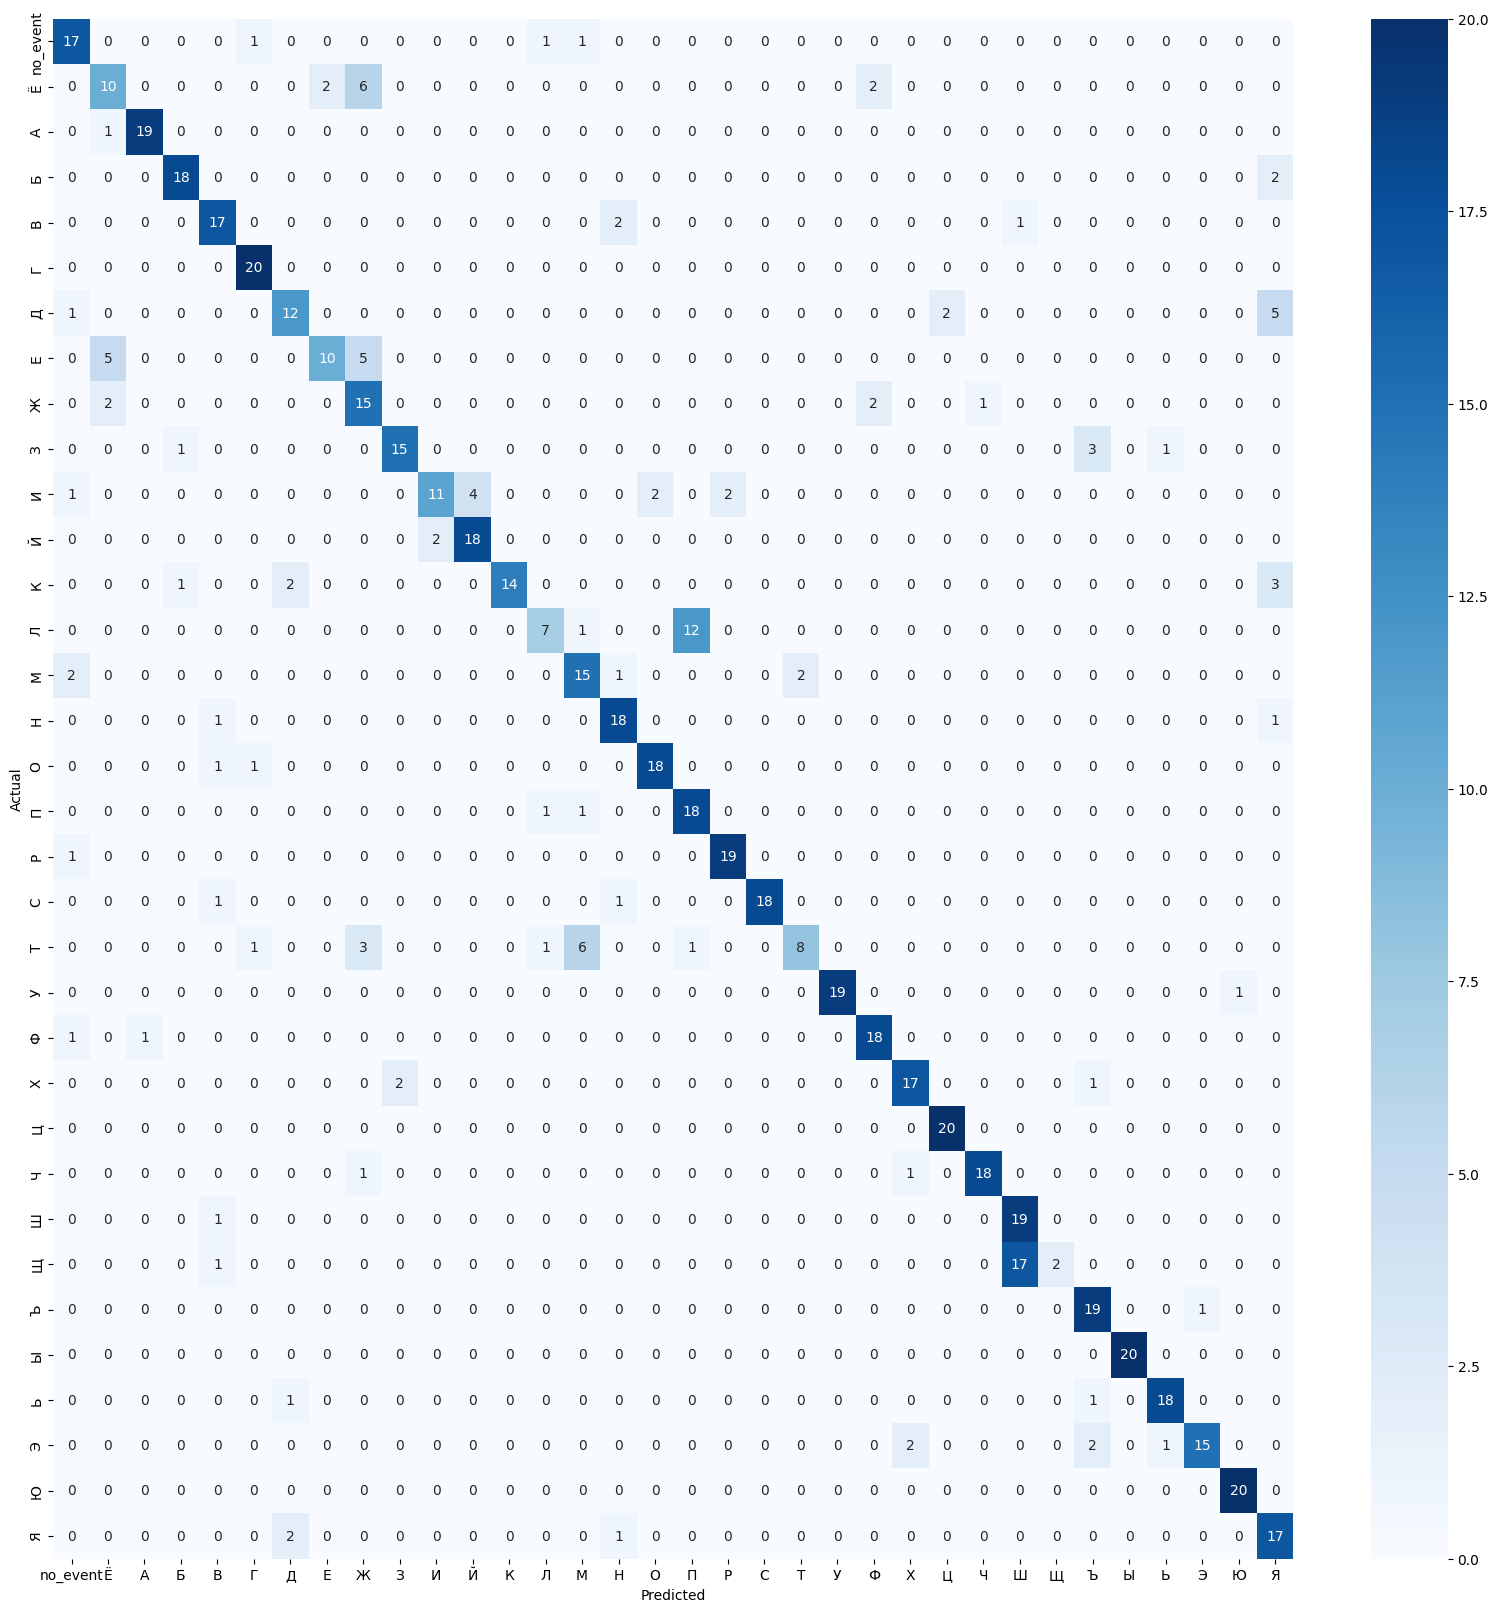

In [ ]:
# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

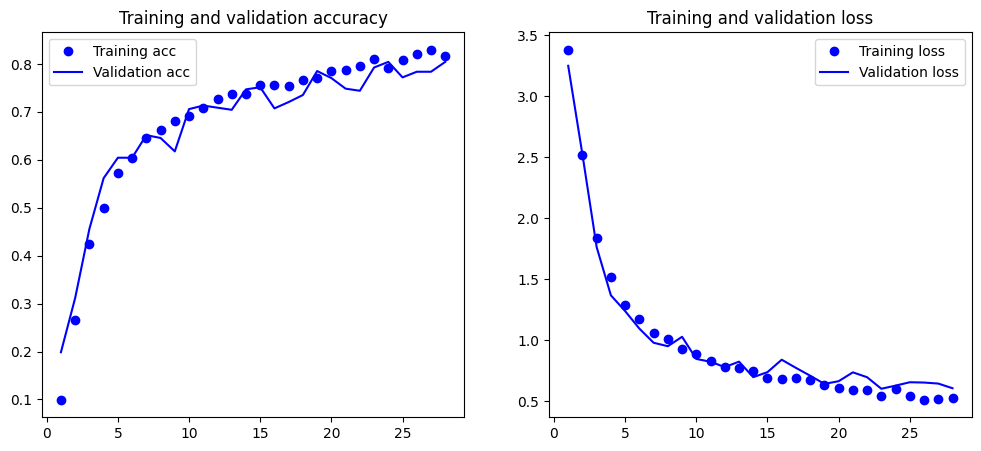

In [ ]:
# Plot training/validation accuracy and loss
def plot_history(history):
    acc = history.history['categorical_accuracy']
    val_acc = history.history['val_categorical_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

# Run the function
plot_history(history)

In [ ]:
model.save('rsl_24f_2d_lstm_standard.keras')

I WILL BE TESTING CONV1D FROM HERE ON OUT

In [ ]:
from keras.layers import Conv1D, MaxPooling1D, Flatten
from keras.optimizers import Adam

model = Sequential([
    # The Conv1D layer scans the sequence for local motion patterns
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(24, 86)),
    MaxPooling1D(pool_size=2), # Reduces dimensionality

    # Then the LSTM analyzes the patterns found by the Conv1D
    LSTM(64, return_sequences=False),

    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(34, activation='softmax')
])
model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['categorical_accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    os.path.join(save_dir, 'best_model_xy_conv1d.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.0523 - loss: 3.6658
Epoch 1: val_loss improved from None to 3.40192, saving model to /content/drive/MyDrive/models/best_model_xy_conv1d.keras

Epoch 1: finished saving model to /content/drive/MyDrive/models/best_model_xy_conv1d.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - categorical_accuracy: 0.0858 - loss: 3.4408 - val_categorical_accuracy: 0.1294 - val_loss: 3.4019
Epoch 2/50
 94/100 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.1960 - loss: 2.8897
Epoch 2: val_loss improved from 3.40192 to 3.07038, saving model to /content/drive/MyDrive/models/best_model_xy_conv1d.keras

Epoch 2: finished saving model to /content/drive/MyDrive/models/best_model_xy_conv1d.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - categorical_accuracy: 0.2348 - loss: 2.7398 - val_categorical_accuracy: 0.3103 - val_loss: 3.0704
Epoch 3/50
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.3286 - loss

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Get predictions on the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# 3. Print Classification Report
print(classification_report(y_true, y_pred, target_names=list(label_map.keys())))

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

    no_event       0.74      0.70      0.72        20
           Ё       0.65      0.55      0.59        20
           А       0.83      0.95      0.88        20
           Б       0.83      0.95      0.88        20
           В       0.95      0.95      0.95        20
           Г       0.95      1.00      0.98        20
           Д       0.83      0.50      0.62        20
           Е       0.67      0.60      0.63        20
           Ж       0.52      0.60      0.56        20
           З       1.00      0.50      0.67        20
           И       0.68      0.75      0.71        20
           Й       0.80      0.60      0.69        20
           К       1.00      0.70      0.82        20
           Л       0.54      0.95      0.69        20
           М       0.52      0.65      0.58        20
           Н       0.94      0.80      0.86        20
           О       0.95      0.95      0.

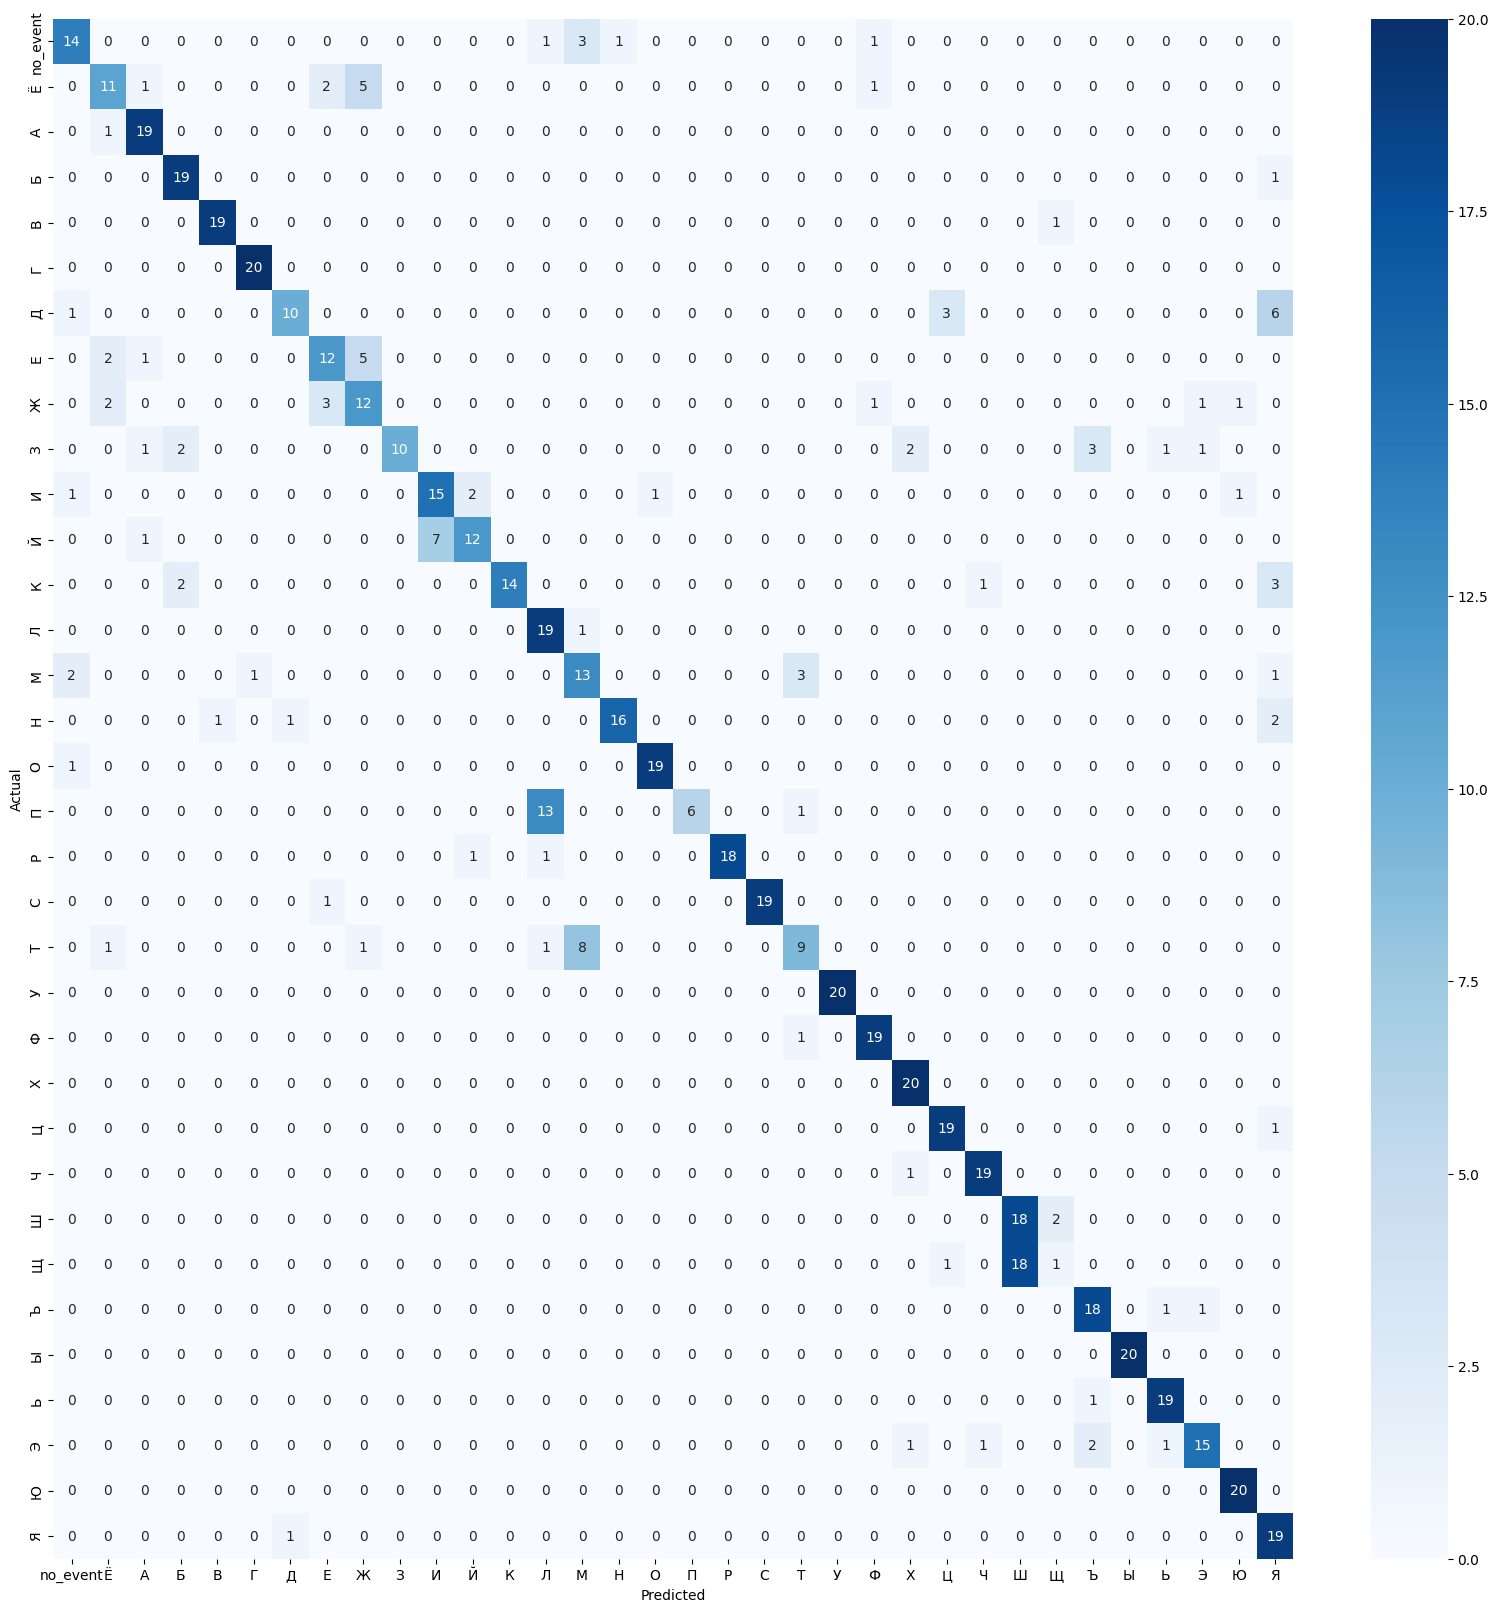

In [ ]:
# 4. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

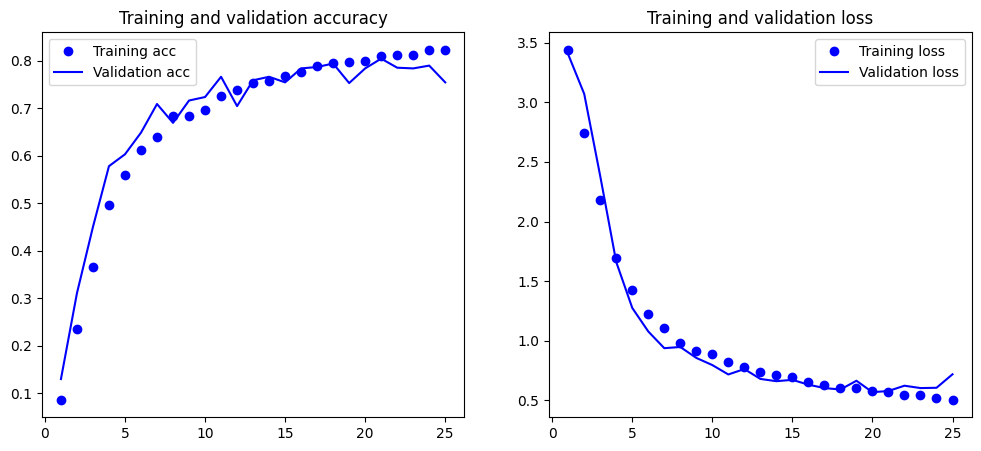

In [ ]:
def plot_history(history):
    acc = history.history['categorical_accuracy']
    val_acc = history.history['val_categorical_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

# Run the function
plot_history(history)

In [ ]:
model.save('rsl_24f_2d_conv1d_standard.keras')